![alt text](header.png)

## Notebook 1 | ML Foundations 

> **Workshop: From Algorithm to Hardware: Machine Learning in Embedded Systems | April 2026**  

This notebook covers the fundamentals of training and evaluating neural networks with a deployment mindset. We use MNIST flattened to 1D vectors as a concrete example. Then, we add CIFAR-10 and a CNN.

### 1. What changes when a model leaves the notebook

In a research notebook, success means accuracy on a test set. In deployment, success means the model runs correctly on a specific device, within a latency budget, using limited memory and energy.

Key questions before deploying:
- **Latency**: how fast must inference be? (real-time < 10ms, near real-time < 100ms)
- **Memory**: how much RAM/flash is available? (MCU: KB range, FPGA: MB range)
- **Energy**: battery-powered or mains?
- **Accuracy tolerance**: what is the minimum acceptable accuracy for this application?

In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Flatten, Conv2D, MaxPooling2D, Dropout

tf.random.set_seed(42)
np.random.seed(42)

2026-04-21 12:33:35.940232: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-21 12:33:35.942056: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-21 12:33:35.980433: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-21 12:33:35.981092: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-21 12:33:36.519401: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Co

In [2]:
# GPU 
os.environ['TF_XLA_FLAGS'] = '--tf_xla_enable_xla_devices'

import tensorflow as tf
print("GPUs: ", len(tf.config.experimental.list_physical_devices('GPU')))

import tensorflow as tf
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)

    except RuntimeError as e:
        print(e)

GPUs:  0


### 2. Load MNIST and flatten to 1D

MNIST contains 28×28 grayscale images of handwritten digits. For an MLP, we flatten each image to a 784-dimensional vector. This is exactly what KalEdge Lite does when you select **Input mode → MLP (Flatten)**.

In [29]:
(X_tr, y_tr), (X_te, y_te) = mnist.load_data()

# Flatten to 1D vectors
X_tr = X_tr.reshape(-1, 784).astype('float32') / 255.0
X_te = X_te.reshape(-1, 784).astype('float32') / 255.0

X_train, X_val, y_train, y_val = train_test_split(
    X_tr, y_tr, test_size=0.1, random_state=42, stratify=y_tr
)

y_train_cat = to_categorical(y_train, 10)
y_val_cat   = to_categorical(y_val,   10)
y_test_cat  = to_categorical(y_te,    10)
# [1 0 0 0 0 0 0 0 0 0]
# [0 1 0 0 0 0 0 0 0 0]
# [0 0 1 0 0 0 0 0 0 0]

print(f'Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_te.shape}')

Train: (54000, 784)  Val: (6000, 784)  Test: (10000, 784)


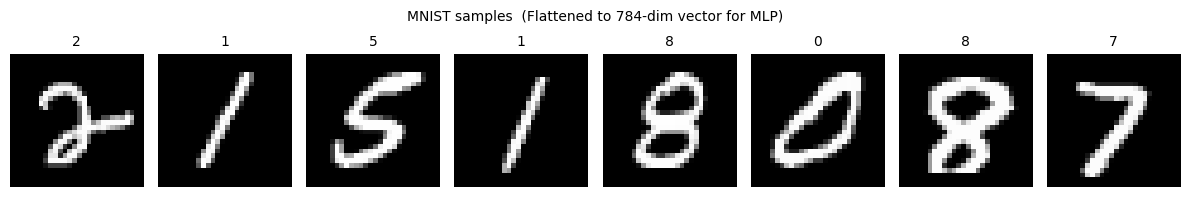

In [30]:
fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i, ax in enumerate(axes):
    ax.imshow(X_train[i].reshape(28, 28), cmap='gray')
    ax.set_title(str(y_train[i]), fontsize=10)
    ax.axis('off')
plt.suptitle('MNIST samples  (Flattened to 784-dim vector for MLP)', fontsize=10)
plt.tight_layout()
plt.show()

### 3. Define and train a baseline MLP

In [31]:
def build_model(input_dim=784, num_classes=10):
    return tf.keras.Sequential([
        tf.keras.layers.Dense(64, activation='relu', input_shape=(input_dim,)),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])

model = build_model()
model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_8 (Dense)             (None, 64)                50240     
                                                                 
 dense_9 (Dense)             (None, 32)                2080      
                                                                 
 dense_10 (Dense)            (None, 10)                330       
                                                                 
Total params: 52,650
Trainable params: 52,650
Non-trainable params: 0
_________________________________________________________________


In [32]:
lr = 1e-3

model.compile(
    optimizer=tf.keras.optimizers.Adam(lr),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

hist = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=20, batch_size=64, verbose=1
)

Epoch 1/20
844/844 [==============================] - 1s 1ms/step - loss: 0.3449 - accuracy: 0.9011 - val_loss: 0.1944 - val_accuracy: 0.9468
Epoch 2/20
844/844 [==============================] - 1s 1ms/step - loss: 0.1552 - accuracy: 0.9553 - val_loss: 0.1592 - val_accuracy: 0.9558
Epoch 3/20
844/844 [==============================] - 1s 1ms/step - loss: 0.1150 - accuracy: 0.9651 - val_loss: 0.1351 - val_accuracy: 0.9618
Epoch 4/20
844/844 [==============================] - 1s 1ms/step - loss: 0.0906 - accuracy: 0.9731 - val_loss: 0.1215 - val_accuracy: 0.9663
Epoch 5/20
844/844 [==============================] - 1s 1ms/step - loss: 0.0743 - accuracy: 0.9771 - val_loss: 0.1119 - val_accuracy: 0.9657
Epoch 6/20
844/844 [==============================] - 1s 1ms/step - loss: 0.0622 - accuracy: 0.9811 - val_loss: 0.1064 - val_accuracy: 0.9705
Epoch 7/20
844/844 [==============================] - 1s 1ms/step - loss: 0.0523 - accuracy: 0.9844 - val_loss: 0.1085 - val_accuracy: 0.9697
Epoch 

### 4. Evaluation metrics that matter for deployment

In [33]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_pred = np.argmax(model.predict(X_te, verbose=0), axis=1)

print('Test accuracy:', np.mean(y_pred == y_te))
print()
print(classification_report(y_te, y_pred))

Test accuracy: 0.9759

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.97      0.98      1032
           3       0.96      0.98      0.97      1010
           4       0.98      0.98      0.98       982
           5       0.98      0.96      0.97       892
           6       0.98      0.99      0.98       958
           7       0.98      0.97      0.97      1028
           8       0.95      0.98      0.96       974
           9       0.98      0.95      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



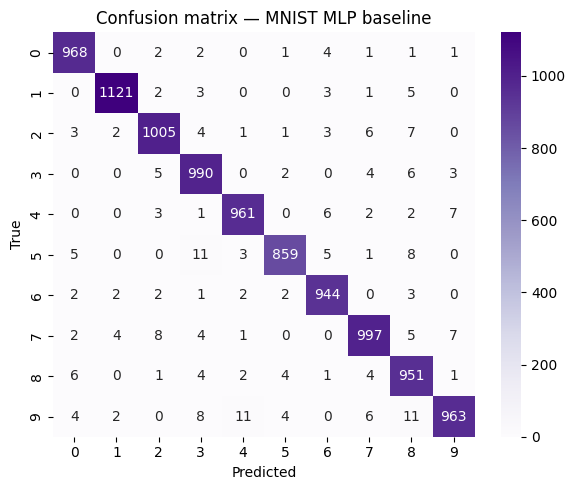

In [34]:
cm = confusion_matrix(y_te, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion matrix — MNIST MLP baseline')
plt.tight_layout()
plt.show()

### 5. Training curves

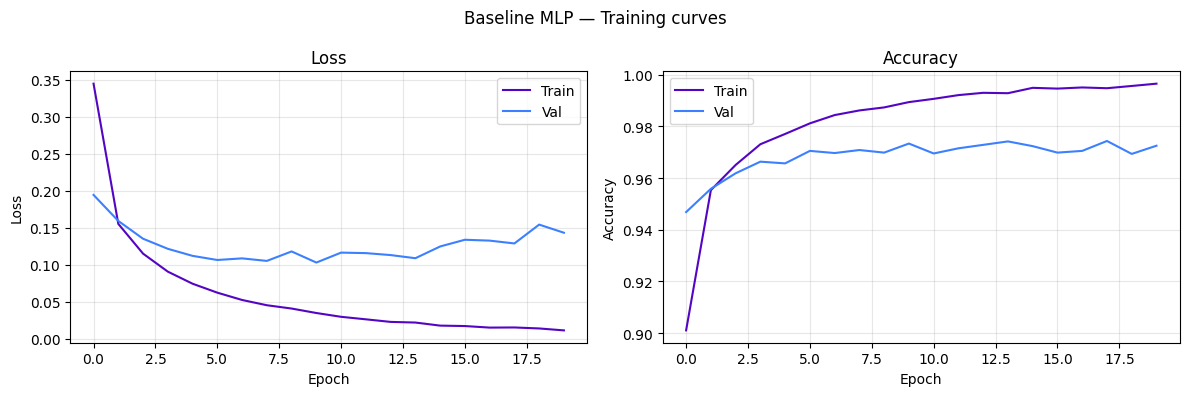

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hist.history['loss'],     label='Train', color='#5405C4')
axes[0].plot(hist.history['val_loss'], label='Val',   color='#3C80FF')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(hist.history['accuracy'],     label='Train', color='#5405C4')
axes[1].plot(hist.history['val_accuracy'], label='Val',   color='#3C80FF')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Baseline MLP — Training curves', fontsize=12)
plt.tight_layout()
plt.show()

### 6. Model size 
#### First look at deployment constraints

In [ ]:
import os
model.save('tmp/baseline_mnist.h5')
size_kb = os.path.getsize('tmp/baseline_mnist.h5') / 1024
params  = model.count_params()

print(f'Parameters : {params:,}')
print(f'File size  : {size_kb:.1f} KB')
print()
print('Typical deployment budgets:')

print('  FPGA (Zynq-7020) : < 53,200 LUTs,   < 220 DSPs')
print('  This model       : needs compression to fit FPGA efficiently')

Parameters : 52,650
File size  : 647.8 KB

Typical deployment budgets:
  FPGA (Zynq-7020) : < 53,200 LUTs,   < 220 DSPs
  This model       : needs compression to fit FPGA efficiently


---

####  Exercise:

Vary the values of batch size, number of epochs, and learning rate.
Generate the corresponding training and validation curves.

What conclusions can you draw about the model’s behavior and performance when these parameters are modified?

#### Experimental Results Summary

| Experiment | Batch Size | Epochs | Learning Rate | Train Accuracy | Validation Accuracy | Test Accuracy | Observations |
|-----------|------------|--------|---------------|----------------|---------------------|---------------|--------------|
| 1 | 32 | 20 | 0.001 | | | | |
| 2 | 50 | 32 | 0.001 | | | | |
| 3 | 100 | 32 | 0.001 | | | | |
| 4 | 50 | 32 | 0.01 | | | | |
| 5 | 50 | 32 | 0.0001 | | | | |


- How does increasing the batch size affect convergence speed and stability?

- What happens when the number of epochs is too small or too large?

- How does the learning rate influence training stability and final accuracy?

- Do you observe signs of overfitting or underfitting in the curves?


### 7. Load CIFAR-10 

We will repeat the previous procedure using the CIFAR-10 dataset. In this case, we will use a 2D Convolutional Neural Network (2D-CNN) architecture.


In [38]:
# Load the CIFAR-10 dataset
(x_train_cifar10, y_train_cifar10), (x_test_cifar10, y_test_cifar10) = cifar10.load_data()



(-0.5, 31.5, 31.5, -0.5)

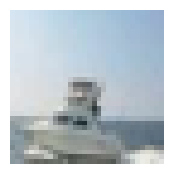

In [39]:
# Size of the image to be displayed
plt.figure(figsize=(2, 2))

# The image corresponds to the N-th element of the dataset
N = 100
plt.imshow(x_train_cifar10[N])
plt.axis('off')

In [40]:
# Normalize the CIFAR-10 dataset
x_train_cifar10_norm, x_test_cifar10_norm = (
    x_train_cifar10 / 255.0,
    x_test_cifar10 / 255.0
)


### 8. Define and train the baseline 2D-CNN

In [41]:
# Definition of a 2D Convolutional Neural Network (CNN) for CIFAR-10

model_2Dconv_cifar10 = Sequential([

    # First convolutional block
    Conv2D(32, (3, 3), activation='relu', padding='same',
           input_shape=(32, 32, 3)),
    MaxPooling2D((2, 2)),

    # Second convolutional block
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    # Third convolutional block
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    # Flatten feature maps into a 1D vector
    Flatten(),

    # Fully connected layer
    Dense(128, activation='relu'),

    # Dropout to reduce overfitting
    Dropout(0.5),

    # Output layer for 10-class classification
    Dense(10, activation='softmax')
])


In [42]:
# Compile the CNN model
from tensorflow.keras.optimizers import SGD, Adam
op = Adam(learning_rate=0.001)

model_2Dconv_cifar10.compile(
    optimizer=op,
    loss='sparse_categorical_crossentropy',  # Used because labels are NOT one-hot encoded
    metrics=['accuracy']
)

# Train the CNN model
history_2Dconv_cifar10 = model_2Dconv_cifar10.fit(
    x_train_cifar10_norm,
    y_train_cifar10,
    epochs=32,
    validation_split=0.2,
    batch_size=64
)


Epoch 1/32
625/625 [==============================] - 10s 14ms/step - loss: 1.7685 - accuracy: 0.3492 - val_loss: 1.4061 - val_accuracy: 0.4911
Epoch 2/32
625/625 [==============================] - 10s 17ms/step - loss: 1.4152 - accuracy: 0.4861 - val_loss: 1.1808 - val_accuracy: 0.5823
Epoch 3/32
625/625 [==============================] - 10s 16ms/step - loss: 1.2462 - accuracy: 0.5540 - val_loss: 1.0713 - val_accuracy: 0.6245
Epoch 4/32
625/625 [==============================] - 10s 16ms/step - loss: 1.1411 - accuracy: 0.5958 - val_loss: 0.9834 - val_accuracy: 0.6644
Epoch 5/32
625/625 [==============================] - 10s 16ms/step - loss: 1.0528 - accuracy: 0.6316 - val_loss: 0.9363 - val_accuracy: 0.6715
Epoch 6/32
625/625 [==============================] - 11s 18ms/step - loss: 0.9858 - accuracy: 0.6540 - val_loss: 0.9363 - val_accuracy: 0.6751
Epoch 7/32
625/625 [==============================] - 11s 17ms/step - loss: 0.9333 - accuracy: 0.6765 - val_loss: 0.8521 - val_accuracy:

### 10.  Training curves

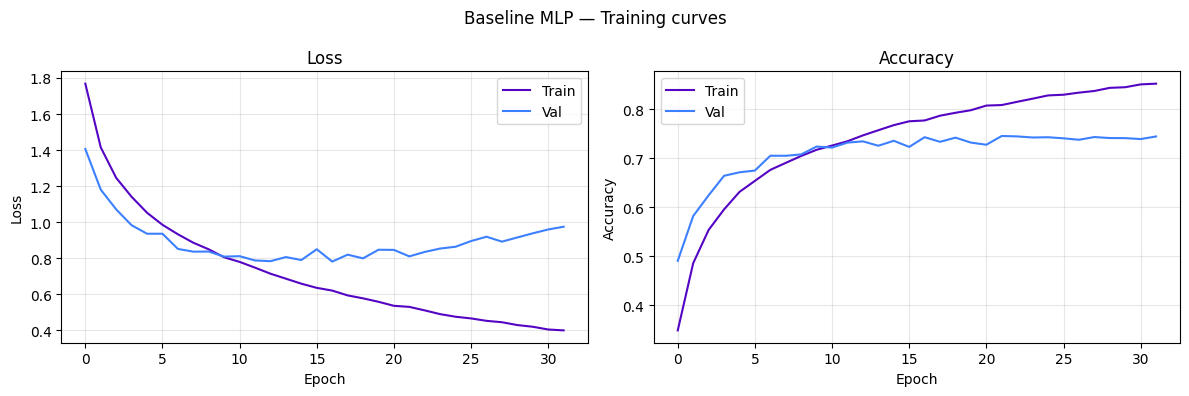

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_2Dconv_cifar10.history['loss'],     label='Train', color='#5405C4')
axes[0].plot(history_2Dconv_cifar10.history['val_loss'], label='Val',   color='#3C80FF')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_2Dconv_cifar10.history['accuracy'],     label='Train', color='#5405C4')
axes[1].plot(history_2Dconv_cifar10.history['val_accuracy'], label='Val',   color='#3C80FF')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Baseline MLP — Training curves', fontsize=12)
plt.tight_layout()
plt.show()

---

#### Excercises: 

- Compute the evaluation metrics for CIFAR-10.

- For MNIST: replace the Flatten layer in the model definition with a Dense layer. For this step, the image must first be reshaped into a 1D vector.

- Compute the relevant metrics to assess and verify the model’s performance.

- For CIFAR-10: select two classes and implement a binary classifier.

---

### Summary for MNIST-MLP

- MNIST flattened to 784-dim vectors is the standard MLP benchmark
- The baseline achieves ~98% accuracy with a 64→32→10 architecture
- File size and parameter count are first proxies for deployability
- In KalEdge Lite, these metrics appear in the metrics panel after training

**Next:** Notebook 2 shows how to compress this model using pruning, quantization and knowledge distillation.